Importaciòn de Librerìas

In [1]:
# --- Manejo de datos ---
import pandas as pd
import numpy as np

# --- Visualización ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Tratamiento de outliers (Winsorizing) ---
from feature_engine.outliers import Winsorizer

# --- Imputación ---
from sklearn.impute import KNNImputer

# --- Cálculo de pendiente (slope) ---
from numpy.polynomial.polynomial import polyfit

# --- Manejo de warnings ---
import warnings
warnings.filterwarnings("ignore")


Cargar el archivo df_completo_con_campo.xlsx

In [2]:
import pandas as pd

# Ruta del archivo (usa r'' para evitar problemas con el backslash)
ruta = r"C:\Users\Vìctor\OneDrive\Desktop\ESP_Project\df_completo_con_campo.xlsx"

# Cargar el DataFrame
df = pd.read_excel(ruta)

print("✅ Dataset cargado correctamente")
print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas\n")

print("🔎 Primeras columnas:")
print(df.columns.tolist())

print("\n🔎 Tipos de datos iniciales:")
print(df.dtypes.head())

# Vista rápida de las primeras filas
df.head()


✅ Dataset cargado correctamente
Dimensiones: 16161 filas × 20 columnas

🔎 Primeras columnas:
['name_', 'date', 'prueba_de_produccion_petróleo_a_24_horas_bbld', 'prueba_de_producción_agua_a_24_horas_bbld', 'prueba_pozooil_24__prueba_pozowater_24', 'prueba_de_producción_gas_a_24_horas_mcfd', 'bsw_pct', 'gravedad_api_del_petroleo', 'salinidad_ppm_pu', 'presion_de_intake_psi', 'frecuencia_bomba_hz', 'amperaje_bomba_amp', 'presion_de_tubing_psi', 'presion_de_casing_psi', 'tipo_de_bomba', 'temperatura_de_la_bomba_deg_f', 'etapas_de_la_bomba', 'campo', 'pozo', 'fecha']

🔎 Tipos de datos iniciales:
name_                                                    object
date                                             datetime64[ns]
prueba_de_produccion_petróleo_a_24_horas_bbld           float64
prueba_de_producción_agua_a_24_horas_bbld               float64
prueba_pozooil_24__prueba_pozowater_24                  float64
dtype: object


,name_,date,prueba_de_produccion_petróleo_a_24_horas_bbld,prueba_de_producción_agua_a_24_horas_bbld,prueba_pozooil_24__prueba_pozowater_24,prueba_de_producción_gas_a_24_horas_mcfd,bsw_pct,gravedad_api_del_petroleo,salinidad_ppm_pu,presion_de_intake_psi,frecuencia_bomba_hz,amperaje_bomba_amp,presion_de_tubing_psi,presion_de_casing_psi,tipo_de_bomba,temperatura_de_la_bomba_deg_f,etapas_de_la_bomba,campo,pozo,fecha
0,SCHAO-473HS1UI,2015-01-07,1488.0,470.0,1958.0,0.0,24.00,18.2,NaN,NaN,NaN,NaN,120.0,NaN,NaN,NaN,NaN,SACHA NORTE 1,SCHAO-473HS1UI,NaN
1,SCHAO-473HS1UI,2015-01-08,1357.0,528.0,1885.0,0.0,28.01,18.2,NaN,NaN,NaN,NaN,110.0,NaN,NaN,NaN,NaN,SACHA NORTE 1,SCHAO-473HS1UI,NaN
2,SCHAO-473HS1UI,2015-02-01,1436.0,359.0,1795.0,0.0,20.00,18.2,NaN,NaN,NaN,NaN,170.0,NaN,NaN,NaN,NaN,SACHA NORTE 1,SCHAO-473HS1UI,NaN
3,SCHAO-473HS1UI,2015-02-12,1159.0,597.0,1756.0,0.0,34.00,18.2,NaN,NaN,NaN,NaN,90.0,NaN,NaN,NaN,NaN,SACHA NORTE 1,SCHAO-473HS1UI,NaN
4,SCHAO-473HS1UI,2015-02-18,1714.0,429.0,2143.0,0.0,20.02,18.2,NaN,NaN,NaN,NaN,150.0,NaN,NaN,NaN,NaN,SACHA NORTE 1,SCHAO-473HS1UI,NaN


In [3]:
# Ejemplo que devuelve un nuevo DataFrame
df = df.drop('fecha', axis=1)

df.head()

,name_,date,prueba_de_produccion_petróleo_a_24_horas_bbld,prueba_de_producción_agua_a_24_horas_bbld,prueba_pozooil_24__prueba_pozowater_24,prueba_de_producción_gas_a_24_horas_mcfd,bsw_pct,gravedad_api_del_petroleo,salinidad_ppm_pu,presion_de_intake_psi,frecuencia_bomba_hz,amperaje_bomba_amp,presion_de_tubing_psi,presion_de_casing_psi,tipo_de_bomba,temperatura_de_la_bomba_deg_f,etapas_de_la_bomba,campo,pozo
0,SCHAO-473HS1UI,2015-01-07,1488.0,470.0,1958.0,0.0,24.00,18.2,NaN,NaN,NaN,NaN,120.0,NaN,NaN,NaN,NaN,SACHA NORTE 1,SCHAO-473HS1UI
1,SCHAO-473HS1UI,2015-01-08,1357.0,528.0,1885.0,0.0,28.01,18.2,NaN,NaN,NaN,NaN,110.0,NaN,NaN,NaN,NaN,SACHA NORTE 1,SCHAO-473HS1UI
2,SCHAO-473HS1UI,2015-02-01,1436.0,359.0,1795.0,0.0,20.00,18.2,NaN,NaN,NaN,NaN,170.0,NaN,NaN,NaN,NaN,SACHA NORTE 1,SCHAO-473HS1UI
3,SCHAO-473HS1UI,2015-02-12,1159.0,597.0,1756.0,0.0,34.00,18.2,NaN,NaN,NaN,NaN,90.0,NaN,NaN,NaN,NaN,SACHA NORTE 1,SCHAO-473HS1UI
4,SCHAO-473HS1UI,2015-02-18,1714.0,429.0,2143.0,0.0,20.02,18.2,NaN,NaN,NaN,NaN,150.0,NaN,NaN,NaN,NaN,SACHA NORTE 1,SCHAO-473HS1UI


Detectar columnas numericas

In [4]:
df_numeric = df.select_dtypes(include=[np.number])

print("Columnas numéricas detectadas:")
df_numeric.columns.tolist()


Columnas numéricas detectadas:


['prueba_de_produccion_petróleo_a_24_horas_bbld',
 'prueba_de_producción_agua_a_24_horas_bbld',
 'prueba_pozooil_24__prueba_pozowater_24',
 'prueba_de_producción_gas_a_24_horas_mcfd',
 'bsw_pct',
 'gravedad_api_del_petroleo',
 'salinidad_ppm_pu',
 'presion_de_intake_psi',
 'frecuencia_bomba_hz',
 'amperaje_bomba_amp',
 'presion_de_tubing_psi',
 'presion_de_casing_psi',
 'temperatura_de_la_bomba_deg_f',
 'etapas_de_la_bomba']

Función para detectar outliers por columna (IQR method)

In [5]:
def detectar_outliers_columna(serie):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1

    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR

    outliers = serie[(serie < limite_inf) | (serie > limite_sup)]

    return {
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "limite_inf": limite_inf,
        "limite_sup": limite_sup,
        "cantidad": outliers.count(),
        "porcentaje": 100 * outliers.count() / len(serie)
    }


Detectar outliers en TODAS las columnas numéricas

In [6]:
# DataFrame donde almacenaremos los resultados
outliers_pozo = []

# Obtener name único de pozos
pozos = df["pozo"].unique()

# Iterar por cada pozo
for p in pozos:
    df_pozo = df[df["pozo"] == p].copy()
    
    # seleccionar solo columnas numéricas en ese pozo
    df_num = df_pozo.select_dtypes(include=[np.number])
    
    for col in df_num.columns:
        resultados = detectar_outliers_columna(df_pozo[col])
        
        outliers_pozo.append({
            "pozo": p,
            "columna": col,
            **resultados
        })

# Pasamos a DataFrame final
outliers_pozo_df = pd.DataFrame(outliers_pozo)

# Mostramos primeras filas
outliers_pozo_df.head()



,pozo,columna,Q1,Q3,IQR,limite_inf,limite_sup,cantidad,porcentaje
0,SCHAO-473HS1UI,prueba_de_produccion_petróleo_a_24_horas_bbld,546.00,709.00,163.00,301.50,953.50,83,18.568233
1,SCHAO-473HS1UI,prueba_de_producción_agua_a_24_horas_bbld,1827.00,3064.00,1237.00,-28.50,4919.50,0,0.000000
2,SCHAO-473HS1UI,prueba_pozooil_24__prueba_pozowater_24,2618.00,3647.00,1029.00,1074.50,5190.50,1,0.223714
3,SCHAO-473HS1UI,prueba_de_producción_gas_a_24_horas_mcfd,13.00,109.06,96.06,-131.09,253.15,5,1.118568
4,SCHAO-473HS1UI,bsw_pct,72.01,84.01,12.00,54.01,102.01,54,12.080537


In [7]:
outliers_pozo_df.tail()

,pozo,columna,Q1,Q3,IQR,limite_inf,limite_sup,cantidad,porcentaje
639,SCHAJ-428TI,amperaje_bomba_amp,20.0,30.0,10.0,5.0,45.0,0,0.000000
640,SCHAJ-428TI,presion_de_tubing_psi,145.0,300.0,155.0,-87.5,532.5,5,1.470588
641,SCHAJ-428TI,presion_de_casing_psi,80.0,150.0,70.0,-25.0,255.0,1,0.294118
642,SCHAJ-428TI,temperatura_de_la_bomba_deg_f,247.0,276.0,29.0,203.5,319.5,0,0.000000
643,SCHAJ-428TI,etapas_de_la_bomba,278.0,462.0,184.0,2.0,738.0,0,0.000000


Ordenar por pozos con más outliers (muy útil para decidir el tratamiento)

In [8]:
outliers_ordenado = (
    outliers_pozo_df
    .sort_values(by=["cantidad"], ascending=False)
)

outliers_ordenado


,pozo,columna,Q1,Q3,IQR,limite_inf,limite_sup,cantidad,porcentaje
62,SCH-106HS,salinidad_ppm_pu,8000.00,8000.0000,0.0000,8000.00000,8000.00000,209,35.067114
214,SCH-127HS,bsw_pct,75.97,76.0200,0.0500,75.89500,76.09500,206,31.790123
412,SCH-018UI,salinidad_ppm_pu,9100.00,9400.0000,300.0000,8650.00000,9850.00000,193,30.345912
523,SCH-087BT,gravedad_api_del_petroleo,26.30,26.3000,0.0000,26.30000,26.30000,150,23.961661
174,SCH-050UI,salinidad_ppm_pu,15300.00,15500.0000,200.0000,15000.00000,15800.00000,130,19.402985
...,...,...,...,...,...,...,...,...,...
81,SCHV-226HS,presion_de_casing_psi,50.00,100.0000,50.0000,-25.00000,175.00000,0,0.000000
87,SCH-124UI,prueba_de_producción_gas_a_24_horas_mcfd,2.00,55.8300,53.8300,-78.74500,136.57500,0,0.000000
88,SCH-124UI,bsw_pct,0.65,68.0175,67.3675,-100.40125,169.06875,0,0.000000
91,SCH-124UI,presion_de_intake_psi,258.00,719.0000,461.0000,-433.50000,1410.50000,0,0.000000


Variables como:

---salinidad_ppm_pu

---gravedad_api_del_petroleo

En muchos pozos:

---son constantes

---o tienen poca variabilidad

---o son medidas por laboratorio, no por sensores

Por lo tanto:

El método IQR produce falsos outliers.
El método NO debe aplicarse a columnas constantes.
Este pozo NO tiene 35% de outliers; solo tiene valores distintos a la constante.

Identificar columnas variables vs. columnas constantes

In [9]:
df_num = df.apply(pd.to_numeric, errors="coerce")


In [10]:
df_num["pozo"] = df["pozo"]
variabilidad = df_num.groupby("pozo").std()
variabilidad.mean().sort_values(ascending=False)



date                                             7.117301e+16
salinidad_ppm_pu                                 4.737364e+03
prueba_pozooil_24__prueba_pozowater_24           4.131185e+02
prueba_de_producción_agua_a_24_horas_bbld        3.674129e+02
presion_de_tubing_psi                            3.357458e+02
presion_de_intake_psi                            3.202251e+02
prueba_de_produccion_petróleo_a_24_horas_bbld    1.850577e+02
etapas_de_la_bomba                               1.063657e+02
prueba_de_producción_gas_a_24_horas_mcfd         6.141463e+01
presion_de_casing_psi                            2.309345e+01
temperatura_de_la_bomba_deg_f                    1.756679e+01
bsw_pct                                          1.477369e+01
frecuencia_bomba_hz                              1.034582e+01
amperaje_bomba_amp                               9.324049e+00
gravedad_api_del_petroleo                        6.286323e-01
name_                                                     NaN
tipo_de_

## INTERPRETACION FISICA VALIOSA
Los datos fueron obtenidos del ORF por lo tantos son datos validos que se hacen 3,4 veces al mes por pozo. Por lo tanto, esas caidas y crecimientos de gran tamano fisicamente es posible. Aqui se debe tener cuidado el aplicar la estadistica

Función para limpiar OUTLIERS FÍSICOS

In [11]:
def limpiar_outliers_fisicos(df):
    
    df = df.copy()
    
    # PRODUCCIÓN < 0 (físicamente imposible)
    prod_cols = [
        "prueba_de_produccion_petróleo_a_24_horas_bbld",
        "prueba_de_producción_agua_a_24_horas_bbld",
        "prueba_pozooil_24__prueba_pozowater_24",
        "prueba_de_producción_gas_a_24_horas_mcfd"
    ]
    for col in prod_cols:
        df.loc[df[col] < 0, col] = np.nan
    
    # BSW
    df.loc[df["bsw_pct"] < 0, "bsw_pct"] = np.nan
    df.loc[df["bsw_pct"] > 100, "bsw_pct"] = np.nan
    
    # API
    df.loc[df["gravedad_api_del_petroleo"] < 5, "gravedad_api_del_petroleo"] = np.nan
    df.loc[df["gravedad_api_del_petroleo"] > 60, "gravedad_api_del_petroleo"] = np.nan
    
    # PRESIONES
    pressure_cols = [
        "presion_de_intake_psi",
        "presion_de_tubing_psi",
        "presion_de_casing_psi"
    ]
    for col in pressure_cols:
        df.loc[df[col] < 0, col] = np.nan
    
    # FRECUENCIA
    df.loc[df["frecuencia_bomba_hz"] < 0, "frecuencia_bomba_hz"] = np.nan
    df.loc[df["frecuencia_bomba_hz"] > 80, "frecuencia_bomba_hz"] = np.nan
    
    # AMPERAJE ESP
    df.loc[df["amperaje_bomba_amp"] < 0, "amperaje_bomba_amp"] = np.nan
    df.loc[df["amperaje_bomba_amp"] > 200, "amperaje_bomba_amp"] = np.nan
    
    # TEMPERATURA ESP
    df.loc[df["temperatura_de_la_bomba_deg_f"] < 100, "temperatura_de_la_bomba_deg_f"] = np.nan
    df.loc[df["temperatura_de_la_bomba_deg_f"] > 400, "temperatura_de_la_bomba_deg_f"] = np.nan
    
    return df


In [12]:
df_clean = limpiar_outliers_fisicos(df)


Comparar antes / después

In [13]:
comparacion = pd.DataFrame({
    "antes": df.isna().sum(),
    "despues": df_clean.isna().sum()
})

comparacion


,antes,despues
name_,0,0
date,0,0
prueba_de_produccion_petróleo_a_24_horas_bbld,0,0
prueba_de_producción_agua_a_24_horas_bbld,0,0
prueba_pozooil_24__prueba_pozowater_24,0,0
prueba_de_producción_gas_a_24_horas_mcfd,0,0
bsw_pct,5,5
gravedad_api_del_petroleo,65,65
salinidad_ppm_pu,2341,2341
presion_de_intake_psi,5213,5213


Bloque de código — Slope Global por Pozo
Asegurar orden temporal

In [14]:
df_clean = df_clean.sort_values(["pozo", "date"])


In [17]:
col_prod = "prueba_pozooil_24__prueba_pozowater_24"

Función para slope_global

In [15]:
import numpy as np

def slope_global(y):
    x = np.arange(len(y))
    m, b = np.polyfit(x, y, 1)
    return m


Calcular slope_global para cada pozo

In [ ]:
declinacion_natural = (
    df_clean.groupby("pozo")[col_prod]
    .apply(slope_global)
    .reset_index()
    .rename(columns={col_prod: "slope_global"})
)


In [22]:
declinacion_natural.head(40)

,pozo,slope_global
0,SCH-007U,2.320065
1,SCH-018UI,1.953199
2,SCH-050UI,1.148170
3,SCH-083HI,0.318076
4,SCH-087BT,1.816479
5,SCH-088T,2.048186
6,SCH-106HS,3.706224
7,SCH-123UI,2.723009
8,SCH-124UI,1.577970
9,SCH-127HS,1.825666


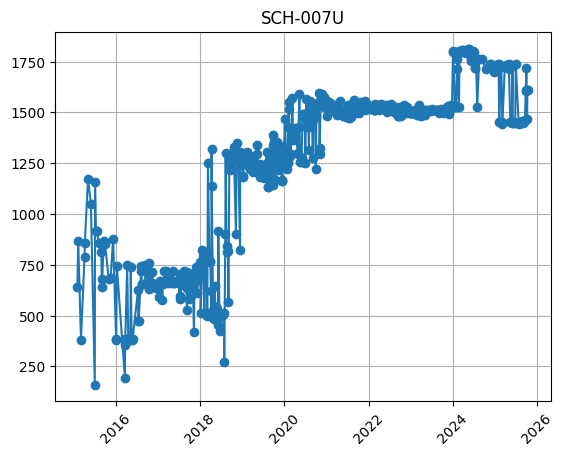

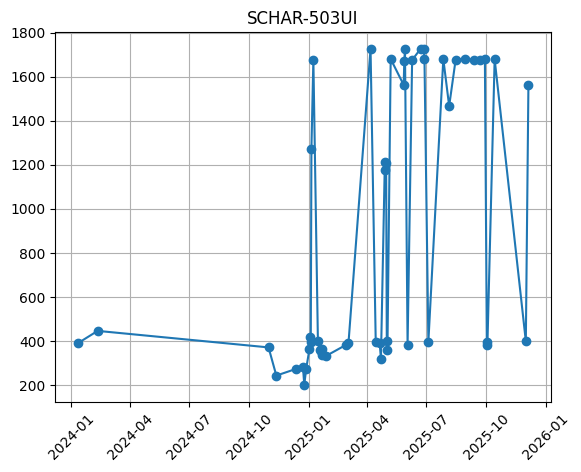

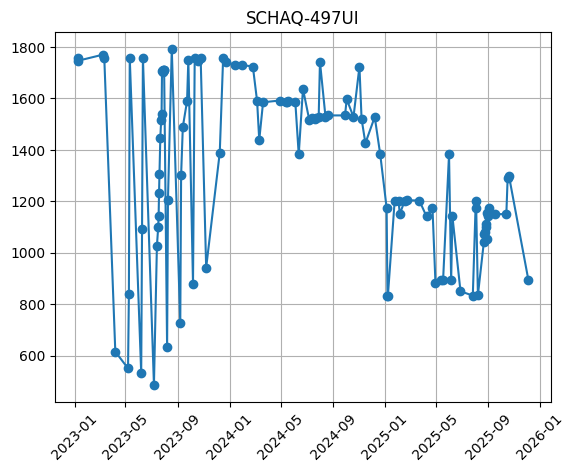

In [24]:
import matplotlib.pyplot as plt

pozo_test = "SCH-007U"
g = df_clean[df_clean["pozo"] == pozo_test]

plt.plot(g["date"], g[col_prod], marker='o')
plt.title(pozo_test)
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

pozo_test = "SCHAR-503UI"
g = df_clean[df_clean["pozo"] == pozo_test]

plt.plot(g["date"], g[col_prod], marker='o')
plt.title(pozo_test)
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

pozo_test = "SCHAQ-497UI"
g = df_clean[df_clean["pozo"] == pozo_test]

plt.plot(g["date"], g[col_prod], marker='o')
plt.title(pozo_test)
plt.xticks(rotation=45)
plt.grid(True)
plt.show()



Definir la función slope_en_ventana(

In [25]:
import numpy as np

def slope_en_ventana(y):
    """
    Calcula la pendiente de una serie y en una ventana usando regresión lineal.
    """
    y = np.array(y)

    # si hay NaN, no calculamos
    if np.isnan(y).any():
        return np.nan
    
    x = np.arange(len(y))
    m, b = np.polyfit(x, y, 1)
    return m


Ordenar el dataframe

In [26]:
df_clean = df_clean.sort_values(["pozo", "date"])


Calcular slope_7 por pozo

In [27]:
df_clean["slope_7"] = (
    df_clean.groupby("pozo")[col_prod]
    .rolling(window=7, min_periods=7)
    .apply(slope_en_ventana, raw=False)
    .reset_index(level=0, drop=True)
)


Calcular slope_14 por pozo

In [28]:
df_clean["slope_14"] = (
    df_clean.groupby("pozo")[col_prod]
    .rolling(window=14, min_periods=14)
    .apply(slope_en_ventana, raw=False)
    .reset_index(level=0, drop=True)
)


Cálculo de umbrales (basados en slope_7)

In [29]:
stats_slope7 = df_clean.groupby("pozo")["slope_7"].agg(["mean", "std"])

stats_slope7["umbral_neg"] = stats_slope7["mean"] - 2 * stats_slope7["std"]
stats_slope7["umbral_pos"] = stats_slope7["mean"] + 2 * stats_slope7["std"]


Función para asignar etiquetas

In [30]:
def etiquetar_slope(row):
    pozo = row["pozo"]
    slope = row["slope_7"]

    u_neg = stats_slope7.loc[pozo, "umbral_neg"]
    u_pos = stats_slope7.loc[pozo, "umbral_pos"]

    if slope < u_neg:
        return 1   # caída anómala
    elif slope > u_pos:
        return 2   # aumento anómalo
    else:
        return 0   # normal


Crear la columna de eventos

In [31]:
df_clean["evento"] = df_clean.apply(etiquetar_slope, axis=1)


In [33]:
df_clean.head(20)

,name_,date,prueba_de_produccion_petróleo_a_24_horas_bbld,prueba_de_producción_agua_a_24_horas_bbld,prueba_pozooil_24__prueba_pozowater_24,prueba_de_producción_gas_a_24_horas_mcfd,bsw_pct,gravedad_api_del_petroleo,salinidad_ppm_pu,presion_de_intake_psi,...,presion_de_tubing_psi,presion_de_casing_psi,tipo_de_bomba,temperatura_de_la_bomba_deg_f,etapas_de_la_bomba,campo,pozo,slope_7,slope_14,evento
9206,SCH-007U,2015-02-02,204.37,435.73,640.10,14.0,68.07,22.4,NaN,NaN,...,100.0,NaN,D725N,NaN,NaN,SACHA NORTE 1,SCH-007U,NaN,NaN,0
9207,SCH-007U,2015-02-09,216.90,652.63,869.53,14.0,75.05,22.4,NaN,NaN,...,50.0,NaN,NaN,NaN,NaN,SACHA NORTE 1,SCH-007U,NaN,NaN,0
9208,SCH-007U,2015-03-05,99.29,281.49,380.78,14.0,73.92,22.4,NaN,NaN,...,290.0,NaN,TD450,NaN,NaN,SACHA NORTE 1,SCH-007U,NaN,NaN,0
9209,SCH-007U,2015-04-05,205.33,585.15,790.48,14.0,74.02,22.4,NaN,NaN,...,260.0,NaN,TD450,NaN,NaN,SACHA NORTE 1,SCH-007U,NaN,NaN,0
9210,SCH-007U,2015-04-07,214.01,642.02,856.03,14.0,75.00,22.4,NaN,NaN,...,50.0,NaN,NaN,NaN,NaN,SACHA NORTE 1,SCH-007U,NaN,NaN,0
9211,SCH-007U,2015-05-05,304.62,867.60,1172.22,14.0,74.01,22.4,NaN,NaN,...,250.0,NaN,NaN,NaN,NaN,SACHA NORTE 1,SCH-007U,NaN,NaN,0
9212,SCH-007U,2015-05-30,273.78,777.95,1051.72,14.0,73.97,22.4,NaN,NaN,...,200.0,NaN,NaN,NaN,NaN,SACHA NORTE 1,SCH-007U,82.696071,NaN,2
9213,SCH-007U,2015-07-03,51.09,108.93,160.02,14.0,68.07,22.4,NaN,NaN,...,120.0,NaN,NaN,NaN,NaN,SACHA NORTE 1,SCH-007U,-14.461071,NaN,0
9214,SCH-007U,2015-07-05,301.73,857.96,1159.69,14.0,73.98,22.4,NaN,NaN,...,250.0,NaN,P18 SSD,NaN,NaN,SACHA NORTE 1,SCH-007U,45.410714,NaN,0
9215,SCH-007U,2015-07-13,229.43,688.30,917.73,14.0,75.00,22.4,NaN,NaN,...,60.0,NaN,P8 SSD,NaN,NaN,SACHA NORTE 1,SCH-007U,-0.826071,NaN,0


In [35]:
import os

# AJUSTA ESTA RUTA copiándola desde el Explorador de archivos
ruta_base = r"C:\Users\Vìctor\OneDrive\Desktop\ESP_Project"
# Crear la carpeta si no existe
os.makedirs(ruta_base, exist_ok=True)

# Guardar en Excel
ruta_excel = os.path.join(ruta_base, "df_clean_slope.xlsx")
df_clean.to_excel(ruta_excel, index=False)
print("✔ Archivo Excel guardado en:", ruta_excel)

✔ Archivo Excel guardado en: C:\Users\Vìctor\OneDrive\Desktop\ESP_Project\df_clean_slope.xlsx


In [36]:
pozo = "SCH-007U"
stats_slope7.loc[pozo]



mean           1.619298
std           22.207717
umbral_neg   -42.796137
umbral_pos    46.034733
Name: SCH-007U, dtype: float64

In [37]:
k = 1.5
stats_slope7["umbral_neg"] = stats_slope7["mean"] - k * stats_slope7["std"]
stats_slope7["umbral_pos"] = stats_slope7["mean"] + k * stats_slope7["std"]


In [39]:
# Seleccionar solo las columnas necesarias
cols = [
    "name_",
    "date",
    "prueba_de_produccion_petróleo_a_24_horas_bbld",
    "prueba_de_producción_agua_a_24_horas_bbld",
    "prueba_pozooil_24__prueba_pozowater_24",
    "slope_7",
    "slope_14",
    "evento"
]

df_eventos = df_clean[cols].copy()

# Ordenar por pozo y fecha para mejor lectura
df_eventos = df_eventos.sort_values(["name_", "date"])

# Mostrar primeras filas
df_eventos.head()


,name_,date,prueba_de_produccion_petróleo_a_24_horas_bbld,prueba_de_producción_agua_a_24_horas_bbld,prueba_pozooil_24__prueba_pozowater_24,slope_7,slope_14,evento
9206,SCH-007U,2015-02-02,204.37,435.73,640.10,NaN,NaN,0
9207,SCH-007U,2015-02-09,216.90,652.63,869.53,NaN,NaN,0
9208,SCH-007U,2015-03-05,99.29,281.49,380.78,NaN,NaN,0
9209,SCH-007U,2015-04-05,205.33,585.15,790.48,NaN,NaN,0
9210,SCH-007U,2015-04-07,214.01,642.02,856.03,NaN,NaN,0


In [40]:
ruta_salida = r"C:\Users\Vìctor\OneDrive\Desktop\ESP_Project\df_eventos.xlsx"

df_eventos.to_excel(ruta_salida, index=False)
print("Archivo generado:", ruta_salida)


Archivo generado: C:\Users\Vìctor\OneDrive\Desktop\ESP_Project\df_eventos.xlsx
